<a href="https://colab.research.google.com/github/Rimas-Codes/free_RAG/blob/main/simple_rag_free.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 Simple RAG — 100% Free Version
**Based on:** [Simple RAG Explained – machinelearningplus.com](https://machinelearningplus.com/gen-ai/simple-rag-explained-a-beginners-guide-to-retrieval-augmented-generation/)

**No API keys required.** All models run locally inside Colab using free HuggingFace libraries.

| Component | Original (paid) | This notebook (free) |
|-----------|----------------|----------------------|
| Embeddings | OpenAI `text-embedding-ada-002` | `sentence-transformers/all-MiniLM-L6-v2` |
| Vector DB | OpenAI + any store | `FAISS` (local, in-memory) |
| LLM | `gpt-3.5-turbo` | `google/flan-t5-base` (HuggingFace) |

---
## What is RAG?
**Retrieval-Augmented Generation (RAG)** gives an LLM access to external knowledge at query time:
1. **Index** your documents → split into chunks → embed each chunk → store in a vector DB
2. **Retrieve** the most relevant chunks for a user question (cosine similarity search)
3. **Generate** an answer by feeding the retrieved chunks as context to an LLM

```
User Question
     │
     ▼
[ Embed Question ] ──► [ Vector DB Search ] ──► Top-K Chunks
                                                      │
                                                      ▼
                                          [ LLM: context + question ]
                                                      │
                                                      ▼
                                                   Answer
```

## Step 0 — Install Dependencies
Run this once. Colab will restart the kernel after install — that's fine.

In [1]:
!pip install -q sentence-transformers faiss-cpu transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 73.3 MB/s eta 0:00:00


## Step 1 — Import Libraries

In [2]:
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer
from transformers import pipeline

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


## Step 2 — The Knowledge Base (Your Documents)

In a real project you'd load PDFs, web pages, or databases. Here we use a small set of
paragraphs about machine learning so you can see the whole pipeline clearly.

Replace `documents` with your own text to build a custom RAG system.

In [3]:
# ---------------------------------------------------------------------------
# 📄 Knowledge base — replace these with your own documents!
# ---------------------------------------------------------------------------
documents = [
    "Machine learning is a subset of artificial intelligence that enables systems to learn and improve from experience without being explicitly programmed. It focuses on developing computer programs that can access data and use it to learn for themselves.",

    "Supervised learning is a type of machine learning where an algorithm is trained on labelled data. The algorithm learns to map inputs to outputs based on example input-output pairs. Common examples include linear regression for continuous outputs and logistic regression for classification.",

    "Unsupervised learning involves training on data that has no labels. The algorithm tries to find hidden patterns or intrinsic structures in the input data. Clustering (e.g. K-Means) and dimensionality reduction (e.g. PCA) are common unsupervised techniques.",

    "A neural network is a series of algorithms that attempt to recognise underlying relationships in a set of data through a process that mimics the way the human brain operates. Neural networks consist of layers of interconnected nodes (neurons).",

    "Deep learning is a subset of machine learning that uses neural networks with many layers (hence 'deep'). It has achieved remarkable results in image recognition, natural language processing, and speech recognition tasks.",

    "Overfitting occurs when a machine learning model learns the training data too well, including its noise and random fluctuations, and therefore performs poorly on new, unseen data. Regularisation techniques such as dropout and L2 penalty help mitigate overfitting.",

    "The bias-variance tradeoff is a fundamental concept in machine learning. High bias means the model is too simple (underfitting). High variance means the model is too complex (overfitting). The goal is to find the sweet spot that minimises total error.",

    "Cross-validation is a technique used to evaluate how well a machine learning model generalises to an independent dataset. The most common form is k-fold cross-validation, where the data is split into k subsets and the model is trained and evaluated k times.",

    "Natural Language Processing (NLP) is a branch of AI that helps computers understand, interpret, and generate human language. Modern NLP is dominated by transformer-based models such as BERT and GPT.",

    "Retrieval-Augmented Generation (RAG) is a technique that combines a retrieval system with a generative model. Instead of relying solely on the model's parametric knowledge, RAG fetches relevant documents from an external store and uses them as context to produce more accurate and grounded answers.",
]

print(f"📚 Knowledge base loaded: {len(documents)} documents")
for i, doc in enumerate(documents):
    print(f"  [{i}] {doc[:80]}...")

📚 Knowledge base loaded: 10 documents
  [0] Machine learning is a subset of artificial intelligence that enables systems to ...
  [1] Supervised learning is a type of machine learning where an algorithm is trained ...
  [2] Unsupervised learning involves training on data that has no labels. The algorith...
  [3] A neural network is a series of algorithms that attempt to recognise underlying ...
  [4] Deep learning is a subset of machine learning that uses neural networks with man...
  [5] Overfitting occurs when a machine learning model learns the training data too we...
  [6] The bias-variance tradeoff is a fundamental concept in machine learning. High bi...
  [7] Cross-validation is a technique used to evaluate how well a machine learning mod...
  [8] Natural Language Processing (NLP) is a branch of AI that helps computers underst...
  [9] Retrieval-Augmented Generation (RAG) is a technique that combines a retrieval sy...


## Step 3 — Chunk the Documents

For longer documents you need to split text into smaller chunks before embedding.
Our example documents are already short, but the chunking function below handles any length.

**Why chunk?** LLMs and embedding models have token limits. Smaller chunks also give more
precise retrieval — you return exactly the relevant paragraph rather than a whole book chapter.

In [4]:
def chunk_text(text: str, chunk_size: int = 200, overlap: int = 50) -> list[str]:
    """
    Split `text` into overlapping word-level chunks.

    Parameters
    ----------
    chunk_size : max number of words per chunk
    overlap    : number of words shared between consecutive chunks
                 (helps the model see cross-boundary context)
    """
    words = text.split()
    chunks = []
    start = 0
    while start < len(words):
        end = start + chunk_size
        chunk = " ".join(words[start:end])
        chunks.append(chunk)
        start += chunk_size - overlap  # slide window with overlap
    return chunks


# Apply chunking — for our short docs this mostly returns 1 chunk per doc
all_chunks = []
for doc in documents:
    all_chunks.extend(chunk_text(doc, chunk_size=60, overlap=10))

print(f"✂️  Total chunks after splitting: {len(all_chunks)}")
for i, chunk in enumerate(all_chunks[:5]):
    print(f"  Chunk {i}: {chunk[:100]}")

✂️  Total chunks after splitting: 10
  Chunk 0: Machine learning is a subset of artificial intelligence that enables systems to learn and improve fr
  Chunk 1: Supervised learning is a type of machine learning where an algorithm is trained on labelled data. Th
  Chunk 2: Unsupervised learning involves training on data that has no labels. The algorithm tries to find hidd
  Chunk 3: A neural network is a series of algorithms that attempt to recognise underlying relationships in a s
  Chunk 4: Deep learning is a subset of machine learning that uses neural networks with many layers (hence 'dee


## Step 4 — Embed the Chunks

We use **`sentence-transformers/all-MiniLM-L6-v2`** — a small, fast, and high-quality
free embedding model. It converts each chunk of text into a 384-dimensional vector.

Semantically similar texts end up close together in this 384-D space — that's what
makes retrieval work.

In [5]:
print("⏳ Loading embedding model (downloads ~90 MB once, cached after that)...")
embed_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

print("🔢 Embedding all chunks...")
chunk_embeddings = embed_model.encode(all_chunks, show_progress_bar=True)
chunk_embeddings = np.array(chunk_embeddings, dtype="float32")

print(f"\n✅ Embedding matrix shape: {chunk_embeddings.shape}")
print(f"   → {chunk_embeddings.shape[0]} chunks × {chunk_embeddings.shape[1]} dimensions")

⏳ Loading embedding model (downloads ~90 MB once, cached after that)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

🔢 Embedding all chunks...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Embedding matrix shape: (10, 384)
   → 10 chunks × 384 dimensions


## Step 5 — Build the FAISS Vector Index

**FAISS** (Facebook AI Similarity Search) is a free, blazing-fast library for
nearest-neighbour search in high-dimensional spaces.

We use `IndexFlatIP` (inner product / cosine similarity on normalised vectors).
Normalising first then using inner product is equivalent to cosine similarity.

In [6]:
# L2-normalise so inner product == cosine similarity
faiss.normalize_L2(chunk_embeddings)

dimension = chunk_embeddings.shape[1]  # 384
index = faiss.IndexFlatIP(dimension)   # Inner Product index
index.add(chunk_embeddings)            # Add all chunk vectors

print(f"✅ FAISS index built")
print(f"   Total vectors indexed: {index.ntotal}")

✅ FAISS index built
   Total vectors indexed: 10


## Step 6 — The Retriever

Given a user query, the retriever:
1. Embeds the query with the same model
2. Searches FAISS for the top-k most similar chunks
3. Returns those chunks as context

In [7]:
def retrieve(query: str, k: int = 3) -> list[dict]:
    """
    Retrieve the top-k most relevant chunks for a given query.

    Returns a list of dicts with keys: 'chunk', 'score', 'index'
    """
    # 1. Embed the query
    query_vec = embed_model.encode([query], show_progress_bar=False)
    query_vec = np.array(query_vec, dtype="float32")
    faiss.normalize_L2(query_vec)

    # 2. Search the index
    scores, indices = index.search(query_vec, k)

    # 3. Collect results
    results = []
    for score, idx in zip(scores[0], indices[0]):
        results.append({
            "chunk": all_chunks[idx],
            "score": float(score),
            "index": int(idx),
        })
    return results


# --- Quick test ---
test_query = "What is overfitting and how do I prevent it?"
results = retrieve(test_query, k=3)

print(f"Query: '{test_query}'\n")
print("Top retrieved chunks:")
for r in results:
    print(f"  [score={r['score']:.3f}] {r['chunk'][:120]}...")

Query: 'What is overfitting and how do I prevent it?'

Top retrieved chunks:
  [score=0.690] Overfitting occurs when a machine learning model learns the training data too well, including its noise and random fluct...
  [score=0.307] The bias-variance tradeoff is a fundamental concept in machine learning. High bias means the model is too simple (underf...
  [score=0.167] Machine learning is a subset of artificial intelligence that enables systems to learn and improve from experience withou...


## Step 7 — Load the Free LLM

We use **`google/flan-t5-base`** — a free instruction-following language model from Google
that runs entirely on Colab's CPU/GPU with no API key.

> **Tip:** For better answers, swap `flan-t5-base` for `flan-t5-large` or `flan-t5-xl`
> if you have GPU memory available (Runtime → Change runtime type → T4 GPU).

In [24]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

print("⏳ Loading LLM (flan-t5-base)...")

model_name = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
llm_model  = AutoModelForSeq2SeqLM.from_pretrained(model_name)

def generate_answer(prompt: str, max_new_tokens: int = 200) -> str:
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        outputs = llm_model.generate(**inputs, max_new_tokens=max_new_tokens)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

print("✅ LLM loaded — no API key needed!")

⏳ Loading LLM (flan-t5-base)...


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


✅ LLM loaded — no API key needed!


## Step 8 — The RAG Pipeline

This is the full end-to-end function:
1. **Retrieve** relevant chunks from FAISS
2. **Build a prompt** that injects those chunks as context
3. **Generate** an answer with the LLM

In [25]:
def rag(query: str, k: int = 3, max_new_tokens: int = 200) -> str:
    """
    Full RAG pipeline:
      Retrieve → Prompt Assembly → Generate

    Parameters
    ----------
    query          : the user's question
    k              : number of chunks to retrieve
    max_new_tokens : maximum length of the generated answer
    """
    # ── Step A: Retrieve ────────────────────────────────────────────────────
    retrieved = retrieve(query, k=k)
    context = "\n\n".join([f"[{i+1}] {r['chunk']}" for i, r in enumerate(retrieved)])

    # ── Step B: Build Prompt ─────────────────────────────────────────────────
    prompt = f"""Answer the question using ONLY the context provided below.
If the answer is not in the context, say "I don't know based on the available information."

Context:
{context}

Question: {query}

Answer :"""

    # ── Step C: Generate ─────────────────────────────────────────────────────
    # output = generator(
    #     prompt,
    #     max_new_tokens=max_new_tokens,
    #     do_sample=False,       # deterministic (greedy)
    # )
    # answer = output[0]["generated_text"].strip()

    # With this:
    answer = generate_answer(prompt, max_new_tokens=max_new_tokens)


    return answer, retrieved


print("✅ RAG pipeline defined and ready.")

✅ RAG pipeline defined and ready.


## Step 9 — Ask Questions!

Now let's run the full RAG system end-to-end.

In [26]:
def ask(question: str):
    """Pretty-print a RAG answer with retrieved sources."""
    print("=" * 70)
    print(f"❓ Question: {question}")
    print("-" * 70)

    answer, retrieved = rag(question, k=3)

    print("📄 Retrieved context chunks:")
    for i, r in enumerate(retrieved):
        print(f"  [{i+1}] (score={r['score']:.3f}) {r['chunk'][:100]}...")

    print()
    print(f"🤖 Answer: {answer}")
    print("=" * 70)
    print()


# --- Test questions ---
ask("What is the difference between supervised and unsupervised learning?")

❓ Question: What is the difference between supervised and unsupervised learning?
----------------------------------------------------------------------
📄 Retrieved context chunks:
  [1] (score=0.727) Unsupervised learning involves training on data that has no labels. The algorithm tries to find hidd...
  [2] (score=0.587) Supervised learning is a type of machine learning where an algorithm is trained on labelled data. Th...
  [3] (score=0.377) Machine learning is a subset of artificial intelligence that enables systems to learn and improve fr...

🤖 Answer: [1]



In [27]:
ask("What is overfitting and how can I prevent it?")

❓ Question: What is overfitting and how can I prevent it?
----------------------------------------------------------------------
📄 Retrieved context chunks:
  [1] (score=0.694) Overfitting occurs when a machine learning model learns the training data too well, including its no...
  [2] (score=0.316) The bias-variance tradeoff is a fundamental concept in machine learning. High bias means the model i...
  [3] (score=0.170) Machine learning is a subset of artificial intelligence that enables systems to learn and improve fr...

🤖 Answer: Regularisation techniques such as dropout and L2 penalty help mitigate overfitting.



In [28]:
ask("How does RAG work?")

❓ Question: How does RAG work?
----------------------------------------------------------------------
📄 Retrieved context chunks:
  [1] (score=0.556) Retrieval-Augmented Generation (RAG) is a technique that combines a retrieval system with a generati...
  [2] (score=0.151) Cross-validation is a technique used to evaluate how well a machine learning model generalises to an...
  [3] (score=0.034) Natural Language Processing (NLP) is a branch of AI that helps computers understand, interpret, and ...

🤖 Answer: RAG fetches relevant documents from an external store and uses them as context to produce more accurate and grounded answers



In [29]:
ask("What is the bias-variance tradeoff?")

❓ Question: What is the bias-variance tradeoff?
----------------------------------------------------------------------
📄 Retrieved context chunks:
  [1] (score=0.784) The bias-variance tradeoff is a fundamental concept in machine learning. High bias means the model i...
  [2] (score=0.269) Overfitting occurs when a machine learning model learns the training data too well, including its no...
  [3] (score=0.113) Cross-validation is a technique used to evaluate how well a machine learning model generalises to an...

🤖 Answer: a fundamental concept in machine learning



In [30]:
# ✏️ Try your own question!
your_question = "What is cross-validation used for?"   # ← change this
ask(your_question)

❓ Question: What is cross-validation used for?
----------------------------------------------------------------------
📄 Retrieved context chunks:
  [1] (score=0.820) Cross-validation is a technique used to evaluate how well a machine learning model generalises to an...
  [2] (score=0.266) Retrieval-Augmented Generation (RAG) is a technique that combines a retrieval system with a generati...
  [3] (score=0.249) Supervised learning is a type of machine learning where an algorithm is trained on labelled data. Th...

🤖 Answer: evaluate how well a machine learning model generalises to an independent dataset



## Step 10 — Visualise Cosine Similarity

Let's see what retrieval actually looks like under the hood — which chunks score highest
for a given query.

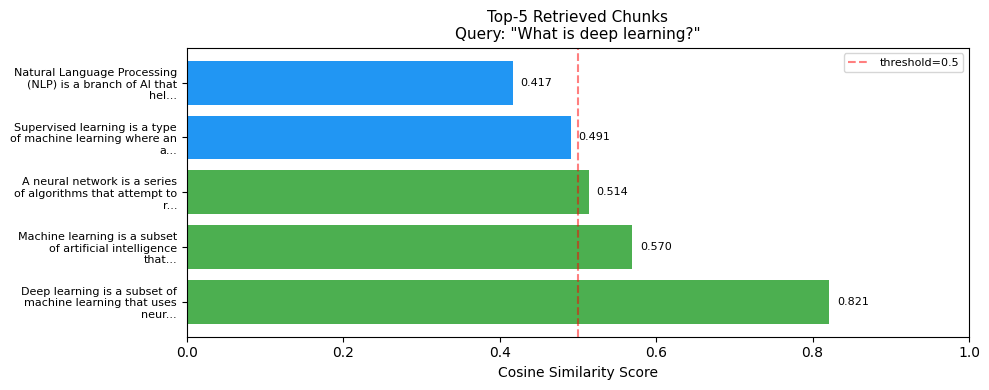

In [31]:
import matplotlib.pyplot as plt
import textwrap

def visualise_retrieval(query: str, k: int = 5):
    results = retrieve(query, k=k)

    labels = [textwrap.fill(r["chunk"][:60] + "...", 30) for r in results]
    scores = [r["score"] for r in results]

    colours = ["#4CAF50" if s > 0.5 else "#2196F3" if s > 0.3 else "#9E9E9E" for s in scores]

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(range(len(labels)), scores, color=colours)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Cosine Similarity Score")
    ax.set_title(f'Top-{k} Retrieved Chunks\nQuery: "{query[:60]}"', fontsize=11)
    ax.set_xlim(0, 1)
    ax.axvline(x=0.5, color="red", linestyle="--", alpha=0.5, label="threshold=0.5")
    ax.legend(fontsize=8)

    for bar, score in zip(bars, scores):
        ax.text(score + 0.01, bar.get_y() + bar.get_height()/2,
                f"{score:.3f}", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()


visualise_retrieval("What is deep learning?", k=5)

## Step 11 — Use Your Own Documents

Replace the `documents` list with your own text below and re-run from Step 3 onwards.
You can also load from a `.txt` file:

In [ ]:
# Option A: Load from a plain text file (upload the file to Colab first)
# with open("my_document.txt", "r") as f:
#     raw_text = f.read()
# documents = [raw_text]  # or split on paragraphs: raw_text.split("\n\n")

# Option B: Paste your own paragraphs here
# documents = [
#     "Your first paragraph here...",
#     "Your second paragraph here...",
# ]

# Then re-run steps 3–8 to rebuild the index over your new documents.
print("📝 Edit this cell with your documents, then re-run from Step 3.")

---
## Summary

| Step | What happened | Tool used |
|------|---------------|-----------|
| 1 | Defined knowledge base | Plain Python list |
| 2 | Split docs into chunks | Custom `chunk_text()` |
| 3 | Embedded chunks → vectors | `sentence-transformers/all-MiniLM-L6-v2` |
| 4 | Built a vector index | `FAISS IndexFlatIP` |
| 5 | Retriever function | Cosine similarity search |
| 6 | Loaded a free LLM | `google/flan-t5-base` |
| 7 | Full RAG pipeline | Retrieve → Prompt → Generate |

### Want better answers?
- Switch to `flan-t5-large` or `flan-t5-xl` (needs GPU in Colab)
- Try `mistralai/Mistral-7B-Instruct-v0.1` with a free HuggingFace Inference API token
- Add more documents to your knowledge base
- Tune `chunk_size`, `overlap`, and `k` for your use case

### Key RAG concepts learned
- **Chunking** — why size and overlap matter
- **Embeddings** — semantic vectors from text
- **Vector similarity search** — how FAISS finds relevant chunks
- **Prompt engineering** — how context is injected into the LLM
- **Grounding** — the model only answers from retrieved docs, reducing hallucination